#Entrenamiento de Dataset Para clasificacion de rendimiento academico
Vamos a analizar el dataset ya procesado para que a partir de la informacion de la region y su informacion academica podamos predecir como será en el futuro el cuartil en el cual se encontrará en otro año futuro
- En este colab realizaremos el entrenamiento de los diferentes modelos que vamos a comparar posteriormente para elegir el de mayor rendimiento. Asimismo, realizaremos previamente el preprocesamiento necesario para su aplicación respectiva.

## Configuración del Entorno y Carga de Librerías
En esta sección se importan las herramientas esenciales para la manipulación de datos, visualización y desarrollo de los modelos predictivos. Además, se configuran las preferencias globales del entorno y se vincula el cuaderno con Google Drive para gestionar el almacenamiento de los datasets.

In [ ]:
#Cargamos librerías y cargamos el directorio de trabajo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def graficar_matriz_confusion(y_true, y_pred, titulo="Matriz de Confusión"):
    """
    Genera un mapa de calor visualmente atractivo para la matriz de confusión.
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))


    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                     linewidths=.5, cbar=True, annot_kws={"size": 14})


    etiquetas = ['Q1', 'Q2', 'Q3', 'Q4']
    ax.set_xticklabels(etiquetas, fontsize=11)
    ax.set_yticklabels(etiquetas, rotation=0, fontsize=11)


    plt.title(titulo, fontsize=16, pad=15, fontweight='bold')
    plt.ylabel('Cuartil Real', fontsize=12, fontweight='bold')
    plt.xlabel('Cuartil Predicho', fontsize=12, fontweight='bold')


    plt.tight_layout()
    plt.show()



##Lectura del Dataset

In [ ]:
path = '/content/drive/MyDrive/dataset_limpio_preprocesado.csv'
path1 = '/content/drive/MyDrive/FACI/2026-1/IA/TA/dataset_limpio_preprocesado.csv' #ESTE ES CON VAB
path2 = '/content/drive/MyDrive/FACI/2026-1/IA/TA/dataset_limpio_preprocesado2.csv'# ESTE NO SE USA
path3 = '/content/drive/MyDrive/FACI/2026-1/IA/TA/dataset_limpio_preprocesado3.csv' #Este es sin VAB



#SOLO UTILIZAR PARA LECTURA LOCAL: COMENTAR SI NO ES EL CASO
df = pd.read_csv(path1, delimiter=',')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   PROVINCIA                                     195 non-null    object 
 1   LECT_EN INICIO_2016                           195 non-null    float64
 2   LECT_EN PROCESO_2016                          195 non-null    float64
 3   LECT_PREVIO AL INICIO_2016                    195 non-null    float64
 4   LECT_SATISFACTORIO_2016                       195 non-null    float64
 5   MAT_EN INICIO_2016                            195 non-null    float64
 6   MAT_EN PROCESO_2016                           195 non-null    float64
 7   MAT_PREVIO AL INICIO_2016                     195 non-null    float64
 8   MAT_SATISFACTORIO_2016                        195 non-null    float64
 9   MEDIDA PROMEDIO COMPRENSION LECTORA_2016      195 non-null    flo

##Ajustes Estructurales
Se descarta la variable nominal `PROVINCIA` para conservar únicamente los atributos numéricos y categóricos codificados que alimentarán los modelos entrenados

In [ ]:
df = df.drop('PROVINCIA', axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 50 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   LECT_EN INICIO_2016                           195 non-null    float64
 1   LECT_EN PROCESO_2016                          195 non-null    float64
 2   LECT_PREVIO AL INICIO_2016                    195 non-null    float64
 3   LECT_SATISFACTORIO_2016                       195 non-null    float64
 4   MAT_EN INICIO_2016                            195 non-null    float64
 5   MAT_EN PROCESO_2016                           195 non-null    float64
 6   MAT_PREVIO AL INICIO_2016                     195 non-null    float64
 7   MAT_SATISFACTORIO_2016                        195 non-null    float64
 8   MEDIDA PROMEDIO COMPRENSION LECTORA_2016      195 non-null    float64
 9   MEDIDA PROMEDIO MATEMATICA_2016               195 non-null    flo

#División de datos de entrenamiento y test
Vamos a separar los datos que usaremos para train y test además, definimos una seed para replicar los resultados posteriormente.
**Recordar**:Nuestro target es el cuartil futuro donde se encontrará la *provincia* en 2024 a partir de informacion de 2016 y 2018

In [ ]:
from sklearn.model_selection import train_test_split

#Definimos el split para el entrenamiento y la prueba

X = df.drop('CUARTIL_2024', axis=1)  # atributos
y = df['CUARTIL_2024'] # target

test_size = 0.20
seed = 4   # Número del grupo, seed definido para replicar experimento

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print('Training: %d registros. Test: %d registros' % (len(y_train), len(y_test)))

Training: 156 registros. Test: 39 registros


##Creacion de los Pipelines a utilizar
En esta parte usaremos los hiperparametros que usaron los papers investigados, además ponemos el parametro `class_weight='balanced'` para que el problema de el desbalance en los datos de clasificacion no afecte al modelo

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

#Empezamos a crear diferentes pipes para cada modelo

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

pipelines = []
pipelines.append(('RegLogistica', make_pipeline(MinMaxScaler(), LogisticRegression(class_weight='balanced', penalty="l2" ))))
pipelines.append(('KNN', make_pipeline(MinMaxScaler(), KNeighborsClassifier( n_neighbors=10, metric='euclidean' ))))
pipelines.append(('ArbolDeDecision', make_pipeline(MinMaxScaler(), DecisionTreeClassifier( class_weight='balanced',max_depth=7 , min_samples_split=2 ))))

##  Diseño de la Estrategia de Validación Cruzada
Para mitigar el sesgo en la estimación del rendimiento y asegurar un proceso de validación robusto ante el tamaño del dataset, se configura una validación cruzada de $K$ iteraciones ($K$-Fold Cross Validation) con 15 particiones. Se fija una semilla usada en train para mantener la consistencia de los subconjuntos.

In [ ]:
from sklearn.model_selection import KFold

#Semilla = Numero del grupo
seed = 42 #semilla usada anteriormente para la separacion de test y train
#NO TOCAR EL KFOLD DEBE SER 42 porque me da buenos resultados asi
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)
kfold


KFold(n_splits=10, random_state=42, shuffle=True)

## Entrenamiento y Evaluación Multimodelo
Se ejecuta el proceso de validación cruzada para cada una de las arquitecturas propuestas. Como métrica de evaluación principal se selecciona `f1_macro`, la cual permite balancear la precisión considerando el desequilibrio que hay dentro de nuestro dataset.

In [ ]:
from sklearn.model_selection import cross_val_score

results = []
names = []

for pipelinename, pipeline in pipelines:
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='f1_macro')
    results.append(cv_results)
    names.append(pipelinename)
    print("{}: {} ({})".format(pipelinename, cv_results.mean(), cv_results.std()))

RegLogistica: 0.5438640526140526 (0.09069331157278647)
KNN: 0.49665903540903533 (0.1005281516282052)
ArbolDeDecision: 0.431656746031746 (0.1666250210748063)


##  Comparación Gráfica del Rendimiento
A continuación, se genera un diagrama de cajas y bigotes (*boxplot*) a partir de los puntajes de F1-Score obtenidos en las 15 iteraciones. Esta visualización permite analizar tanto el desempeño promedio como la dispersión y consistencia de cada modelo evaluado.

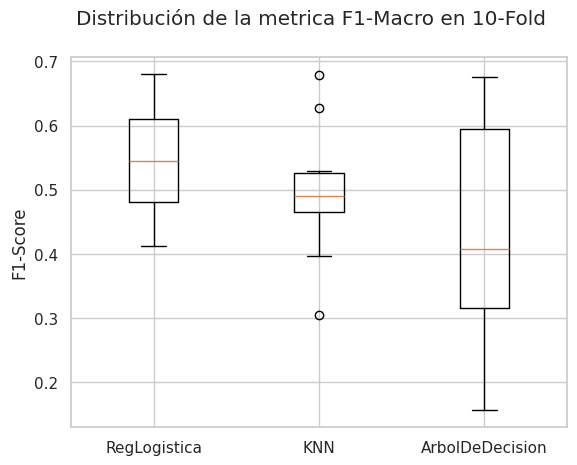

In [ ]:
# Evaluamos gráficamente a partir de los resultados
fig = plt.figure()
fig.suptitle('Distribución de la metrica F1-Macro en 10-Fold')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.ylabel('F1-Score') #hace referencia a F1-weighted
plt.show()


Matriz de Confusión:
[[12  2  0  0]
 [ 1  5  1  1]
 [ 0  1  3  3]
 [ 0  1  0  9]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        14
           1       0.56      0.62      0.59         8
           2       0.75      0.43      0.55         7
           3       0.69      0.90      0.78        10

    accuracy                           0.74        39
   macro avg       0.73      0.70      0.70        39
weighted avg       0.76      0.74      0.74        39



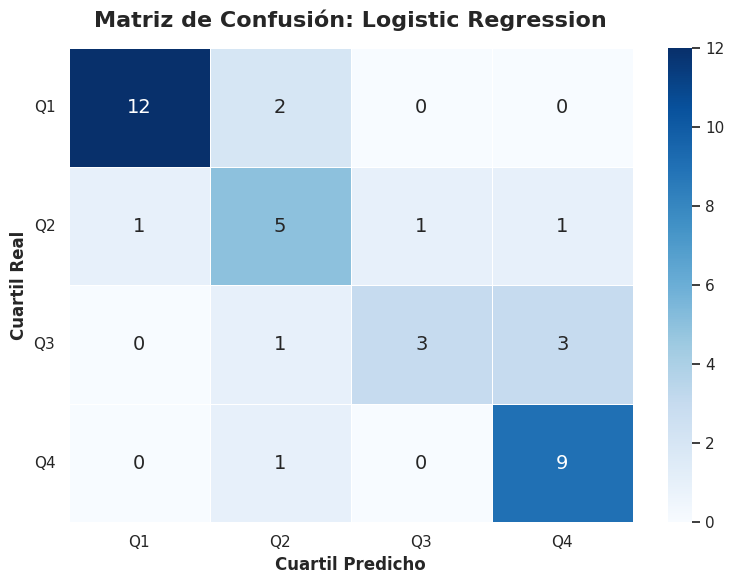

In [ ]:
# @title
pipeline = make_pipeline(MinMaxScaler(), LogisticRegression( class_weight='balanced', penalty="l2" ))

pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
#print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: Logistic Regression")


**Analisis**: Como podemos observar Logistic Regresion tiene rendimiento relativamente mejor comparado con KNN y decisionTree en el diagrama de cajas. Y eso mismo podemos evidenciarlo tambien en la media de este

## 8. Búsqueda de Hiperparámetros Óptimos
Con el fin de maximizar el rendimiento de los clasificadores, se implementa una búsqueda aleatoria (`RandomizedSearchCV`). Este enfoque evalúa de manera eficiente distintas combinaciones de hiperparámetros en un espacio definido mediante validación cruzada ($K=20$), permitiendo encontrar la configuración más robusta para cada modelo.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Definición de mallas de hiperparámetros
param_grid_lr = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver': ['saga', 'liblinear']
}

param_grid_knn = {
    'kneighborsclassifier__n_neighbors': list(range(14, 24)),
    'kneighborsclassifier__weights': ['uniform'],
    'kneighborsclassifier__metric': [ 'manhattan', 'minkowski']
}

param_grid_dt = {
    'decisiontreeclassifier__max_depth': [None,2,3,4,8, 10, 15],
    'decisiontreeclassifier__min_samples_split':[ 2,4,3,5, 10,15],

    'decisiontreeclassifier__criterion': ['gini', 'entropy']
}
#'f1_weighted'
# Configuración de los optimizadores
random_search_lr = RandomizedSearchCV(pipelines[0][1], param_distributions=param_grid_lr, n_iter=10, cv=kfold, scoring='f1_macro', random_state=seed, n_jobs=-1)
random_search_knn = RandomizedSearchCV(pipelines[1][1], param_distributions=param_grid_knn, n_iter=15, cv=kfold, scoring='f1_macro', random_state=seed, n_jobs=-1)
random_search_dt = RandomizedSearchCV(pipelines[2][1], param_distributions=param_grid_dt, n_iter=10, cv=kfold, scoring='f1_macro', random_state=seed, n_jobs=-1)

# Ejecución del entrenamiento y búsqueda
print("Optimizando Regresión Logística...")
random_search_lr.fit(X_train, y_train)

print("Optimizando KNN...")
random_search_knn.fit(X_train, y_train)

print("Optimizando Árbol de Decisión...")
random_search_dt.fit(X_train, y_train)

# Despliegue de los mejores resultados
print(f"\nMejor F1 (Regresión Logística): {random_search_lr.best_score_:.4f} usando {random_search_lr.best_params_}")
print(f"Mejor F1 (KNN): {random_search_knn.best_score_:.4f} usando {random_search_knn.best_params_}")
print(f"Mejor F1 (Árbol de Decisión): {random_search_dt.best_score_:.4f} usando {random_search_dt.best_params_}")

Optimizando Regresión Logística...
Optimizando KNN...
Optimizando Árbol de Decisión...

Mejor F1 (Regresión Logística): 0.5261 usando {'logisticregression__solver': 'liblinear', 'logisticregression__penalty': 'l2', 'logisticregression__C': 10}
Mejor F1 (KNN): 0.5450 usando {'kneighborsclassifier__weights': 'uniform', 'kneighborsclassifier__n_neighbors': 22, 'kneighborsclassifier__metric': 'manhattan'}
Mejor F1 (Árbol de Decisión): 0.4878 usando {'decisiontreeclassifier__min_samples_split': 2, 'decisiontreeclassifier__max_depth': 3, 'decisiontreeclassifier__criterion': 'gini'}


##Haciendo el Test final de los modelos

###KNN

Balanced Accuracy score: 0.6178571428571429

Matriz de Confusión:
[[13  0  1  0]
 [ 1  4  2  1]
 [ 0  3  1  3]
 [ 0  1  0  9]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.50      0.50      0.50         8
           2       0.25      0.14      0.18         7
           3       0.69      0.90      0.78        10

    accuracy                           0.69        39
   macro avg       0.59      0.62      0.60        39
weighted avg       0.66      0.69      0.67        39



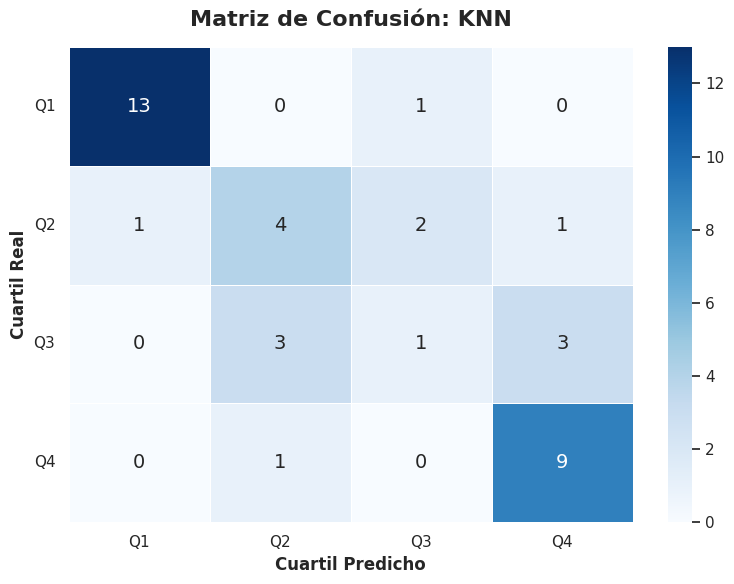

In [ ]:
# @title



# Reentrena el pipeline con con todos los datos de entrenamiento y lo prueba en el conjunto de validación
#KNeighborsClassifier(n_neighbors=17,weights='uniform',metric='minkowski')
pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=22,weights='uniform',metric='manhattan'))
pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: KNN")


###Decision Tree

Balanced Accuracy score: 0.5366071428571428

Matriz de Confusión:
[[9 3 1 1]
 [5 3 0 0]
 [2 1 3 1]
 [0 0 3 7]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.56      0.64      0.60        14
           1       0.43      0.38      0.40         8
           2       0.43      0.43      0.43         7
           3       0.78      0.70      0.74        10

    accuracy                           0.56        39
   macro avg       0.55      0.54      0.54        39
weighted avg       0.57      0.56      0.56        39



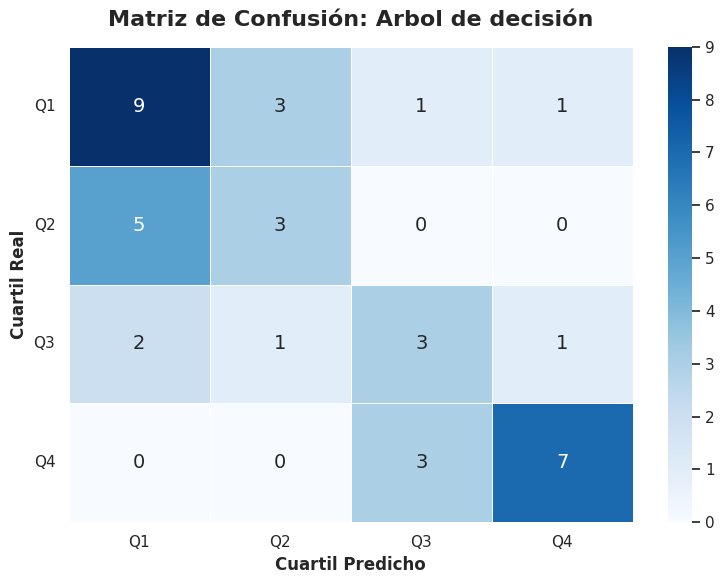

In [ ]:
# @title
pipeline = make_pipeline(MinMaxScaler(), DecisionTreeClassifier( max_depth=8 , min_samples_split=10,criterion='entropy' ))

pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: Arbol de decisión")


###Logistic Regresion

Balanced Accuracy score: 0.7133928571428572

Matriz de Confusión:
[[12  2  0  0]
 [ 2  5  0  1]
 [ 0  1  4  2]
 [ 0  2  0  8]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        14
           1       0.50      0.62      0.56         8
           2       1.00      0.57      0.73         7
           3       0.73      0.80      0.76        10

    accuracy                           0.74        39
   macro avg       0.77      0.71      0.73        39
weighted avg       0.78      0.74      0.75        39



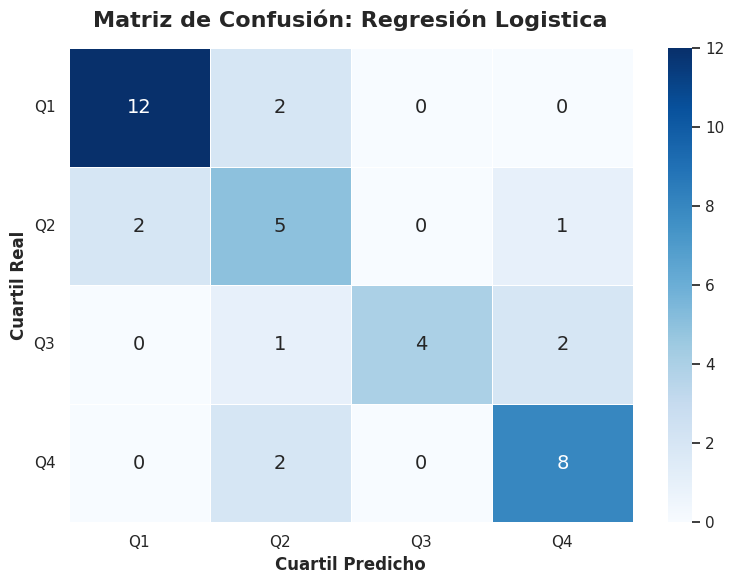

In [ ]:
# @title
pipeline = make_pipeline(MinMaxScaler(), LogisticRegression( C=10 , penalty='l2' , solver='liblinear',class_weight='balanced'))

pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: Regresión Logistica")


#FIN